# Neural ODEs and universal differential equations

Notebook `01_gradients_and_autodiff` established that you can take a derivative
through a hydrologic model. This one asks the harder question: derivative
through *what*, exactly? Your model is a time loop, but the thing you believe in
is a differential equation, and those are not quite the same object.

Getting that distinction straight is what lets us state the organizing idea of
the whole workshop — the **universal differential equation** — and place every
hybrid model you will meet today somewhere on one short list.

:::{admonition} Time check — 20 minutes
:class: tip
What you'll be able to do afterwards:

- write your conceptual model as $d\mathbf{u}/dt = f(\mathbf{u}, \mathbf{x},
  \boldsymbol{\theta}, t)$ and say which solver you are implicitly using
- explain discretize-then-optimize versus the continuous adjoint, and choose
  between them for a given model
- name the five canonical hybrid forms and say which one *your* model would be
- read a learned closure back out of a trained model and check it against the
  physics you know
:::

## Motivation

A conceptual rainfall-runoff model is almost always written as an update rule:
storage today equals storage yesterday plus inflow minus outflow. That is an
implementation detail masquerading as a model. The model is a balance equation
in continuous time; the update rule is one particular, usually first-order,
numerical solution of it — a choice with real consequences for both simulation
and calibration {cite}`clark2010ancient, kavetski2010ancient`.

Once you see it that way, two doors open. You can differentiate *through the
solver* — and there turn out to be two genuinely different ways to do that, with
different memory and stability costs. And you can replace any term on the
right-hand side with something learned, which is the entire hybrid-modeling
research program in one sentence.

## What we'll cover

1. From a discrete update to a differential equation
2. Differentiating through the solver: the tape and the adjoint
3. The neural ODE — when the whole right-hand side is a network
4. Universal differential equations: the five forms
5. A worked UDE — learning the storage-discharge relation
6. Where PINNs sit, briefly and honestly

In [1]:
# --- Colab bootstrap: installs the workshop package on first run -----------
try:
    import workshop_utils
except ImportError:
    %pip install -q "git+https://github.com/BennettHydroLab/differentiable_modeling_workshop.git"
    import workshop_utils

In [2]:
import math
import time

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from workshop_utils import nse, set_style, COLORS, MLP, rk4_step, odeint_fixed
from workshop_utils.data import load_basin, split_by_water_year, BASIN_TEMPERATE

set_style()
torch.manual_seed(0)

print(f"torch {torch.__version__} — ready.")

torch 2.14.0+cu130 — ready.


## 1. From a discrete update to a differential equation

Here is the linear reservoir, the simplest thing in hydrology. Storage drains in
proportion to itself:

$$\frac{du}{dt} = -k\,u, \qquad u(0) = u_0 \quad\Longrightarrow\quad u(t) = u_0 e^{-kt}.$$

You have almost certainly coded it as `S = S - k*S*dt`. That line *is* a
numerical method — forward Euler — and writing it that way silently commits you
to a solver you never chose. Write the right-hand side instead, and the solver
becomes a decision you make on purpose.

In the workshop's notation $\mathbf{u}$ is the state, $\mathbf{x}$ the forcings,
$\boldsymbol{\theta}$ the physical parameters, and $f$ the known physics:

$$\frac{d\mathbf{u}}{dt} = f(\mathbf{u}, \mathbf{x}, \boldsymbol{\theta}, t).$$

`workshop_utils.rk4_step` and `odeint_fixed` implement fourth-order Runge-Kutta
in pure torch operations, so autograd walks straight through them. Before we
trust them for anything, check them against the analytic solution — this is the
habit worth keeping.

In [3]:
k = 0.3           # 1/day — a reservoir with a ~3.3 day residence time
u0 = 100.0        # mm

def f_reservoir(t, u):
    return -k * u


print(f"{'steps':>8}{'dt (d)':>10}{'max error':>14}{'ratio':>9}")
print("-" * 41)
prev = None
for n in [5, 10, 20, 40, 80]:
    t = torch.linspace(0., 10., n + 1, dtype=torch.float64)
    u = odeint_fixed(f_reservoir, torch.tensor([u0], dtype=torch.float64), t)
    exact = u0 * torch.exp(-k * t)
    err = float((u[:, 0] - exact).abs().max())
    ratio = f"{prev/err:>8.1f}" if prev else " " * 8
    print(f"{n:>8}{10/n:>10.4f}{err:>14.3e}{ratio}")
    prev = err

   steps    dt (d)     max error    ratio
-----------------------------------------
       5    2.0000     6.461e-02        
      10    1.0000     3.174e-03    20.4
      20    0.5000     1.757e-04    18.1
      40    0.2500     1.032e-05    17.0
      80    0.1250     6.255e-07    16.5


Halving the step size cuts the error by roughly sixteen, which is
$2^4$ — fourth-order convergence, exactly as advertised. The solver does what it
claims. Now we can use it.

:::{admonition} Why this matters for hydrology
:class: note
Daily conceptual models are usually forward Euler at $\Delta t = 1$ day, and that
is often fine, because the forcing data are daily anyway and the parameters
absorb the discretization error during calibration. But those absorbed errors are
now *part of your calibrated parameters*, which is the point Clark and Kavetski
make at length {cite}`clark2010ancient`. A hybrid model makes this sharper: a
network with enough capacity can learn to compensate for solver error instead of
improving the physics, and {cite}`kalauni2025hybrid` names this as an open risk
in their own work.
:::

## 2. Differentiating through the solver

There are two ways to get $\partial\mathcal{L}/\partial\boldsymbol{\theta}$ when
$\mathcal{L}$ depends on the solution of an ODE, and the difference between them
is not cosmetic.

**Discretize-then-optimize (DTO).** Run the solver. Autograd tapes every
operation the solver performed. Backpropagate through the tape. This is what
notebook 01 did, and what you get for free by writing your model in torch. The
gradient is the *exact* derivative of the number you actually computed, kinks and
all. The cost is memory: the tape is proportional to the number of steps.

**Optimize-then-discretize (OTD), the continuous adjoint.** Derive, on paper, a
second ODE whose solution is the gradient, then solve *that* numerically. Chen et
al. {cite}`chen2018neural` made this famous for neural ODEs. Introduce the
adjoint $\boldsymbol{\lambda}(t) = \partial\mathcal{L}/\partial\mathbf{u}(t)$;
it satisfies

$$\frac{d\boldsymbol{\lambda}}{dt} = -\boldsymbol{\lambda}^\top
  \frac{\partial f}{\partial \mathbf{u}}, \qquad
  \boldsymbol{\lambda}(t_{\text{end}}) = \frac{\partial\mathcal{L}}{\partial \mathbf{u}(t_{\text{end}})},
  \qquad
  \frac{\partial\mathcal{L}}{\partial\boldsymbol{\theta}} =
  -\int_{t_{\text{end}}}^{0} \boldsymbol{\lambda}^\top
  \frac{\partial f}{\partial\boldsymbol{\theta}}\,dt .$$

Integrate that backwards from $t_{\text{end}}$ to $0$ and you have the gradient
without ever having stored the forward trajectory — you recover
$\mathbf{u}(t)$ on the way back by solving the original ODE in reverse alongside
the adjoint. Memory is $O(1)$ in the number of steps.

(The derivation is a Lagrange-multiplier argument: append
$\int \boldsymbol{\lambda}^\top(\dot{\mathbf{u}} - f)\,dt$ to the loss, integrate
by parts, and choose $\boldsymbol{\lambda}$ to annihilate the terms you cannot
evaluate. If you want it in full, it is in the presenter's
`1_neural_ode_adjoint` course notebook. We are going to take it as given and
check it numerically instead, which is more useful in the next ten minutes.)

Let's do both on the linear reservoir, with a loss
$\mathcal{L} = (u(t_{\text{end}}) - 20)^2$ and the recession constant $k$ as the
parameter. We know the answer analytically, so we can grade both methods.

In [4]:
t_end, n_steps = 5.0, 200

# ---- route A: discretize-then-optimize (tape the solver) ------------------
kk = torch.tensor(k, requires_grad=True)
t_grid = torch.linspace(0., t_end, n_steps + 1)
traj = odeint_fixed(lambda t, u: -kk * u, torch.tensor(u0), t_grid)
loss = (traj[-1] - 20.0) ** 2
loss.backward()
g_dto = kk.grad.item()

# ---- the answer we can write down ----------------------------------------
u_end = u0 * math.exp(-k * t_end)
g_exact = 2 * (u_end - 20.0) * (-t_end * u0 * math.exp(-k * t_end))

print(f"u(t_end)            : {u_end:.4f} mm")
print(f"dL/dk, DTO (autograd): {g_dto:.6f}")
print(f"dL/dk, analytic      : {g_exact:.6f}")

u(t_end)            : 22.3130 mm
dL/dk, DTO (autograd): -516.101196
dL/dk, analytic      : -516.103634


In [5]:
def adjoint_gradient(k_value, t_end=5.0, n_rev=200, u_end=None):
    """Continuous adjoint: one backward solve, no stored trajectory.

    The augmented state is z = [u, lambda, dL/dk]. We integrate all three
    backwards together — u so that the adjoint equation has a state to
    linearize about, which is exactly the part that can go wrong.
    """
    kv = torch.tensor(k_value, dtype=torch.float64)

    def augmented(t, z):
        u, lam, _ = z[0], z[1], z[2]
        du = -kv * u                    # the original ODE, run in reverse
        dlam = kv * lam                 # -lam * df/du,  df/du = -k
        dgrad = -lam * (-u)             # -lam * df/dk,  df/dk = -u
        return torch.stack([du, dlam, dgrad])

    t = torch.linspace(0., t_end, n_rev + 1, dtype=torch.float64)
    z = torch.stack([u_end, 2 * (u_end - 20.0), torch.tensor(0., dtype=torch.float64)])
    for i in range(n_rev, 0, -1):
        z = rk4_step(augmented, z, t[i], t[i - 1] - t[i])
    return z[2].item(), z[0].item()     # gradient, and the recovered u(0)


u_end_t = torch.tensor(u0 * math.exp(-k * t_end), dtype=torch.float64)
g_adj, u0_recovered = adjoint_gradient(k, u_end=u_end_t)

print(f"dL/dk, adjoint       : {g_adj:.6f}")
print(f"dL/dk, analytic      : {g_exact:.6f}")
print(f"relative difference  : {abs(g_adj - g_exact)/abs(g_exact):.2e}")
print(f"u(0) recovered by the reverse solve: {u0_recovered:.4f}  (true value {u0})")

dL/dk, adjoint       : -516.103634
dL/dk, analytic      : -516.103634
relative difference  : 6.57e-11
u(0) recovered by the reverse solve: 100.0000  (true value 100.0)


Same gradient, two completely different routes. (The DTO run is float32, the
adjoint float64, which is why one matches to six digits and the other to ten —
the difference is dtype, not method.)

### What DTO costs: the tape

The tape is not free, and it is worth seeing how big it actually is. Every RK4
step evaluates $f$ four times and does a handful of arithmetic operations, and
every one of those becomes a node autograd must keep.

In [6]:
def count_graph_nodes(tensor):
    seen, stack, n = set(), [tensor.grad_fn], 0
    while stack:
        fn = stack.pop()
        if fn is None or fn in seen:
            continue
        seen.add(fn)
        n += 1
        stack.extend(nxt for nxt, _ in fn.next_functions)
    return n


print(f"{'solver steps':>14}{'graph nodes':>14}{'per step':>11}")
print("-" * 39)
for n in [100, 200, 400, 800, 1600]:
    kk = torch.tensor(k, requires_grad=True)
    t = torch.linspace(0., t_end, n + 1)
    tr = odeint_fixed(lambda t_, u: -kk * u, torch.tensor(u0), t)
    n_nodes = count_graph_nodes((tr[-1] - 20.) ** 2)
    print(f"{n:>14}{n_nodes:>14,}{n_nodes/n:>11.1f}")

  solver steps   graph nodes   per step
---------------------------------------


           100         2,105       21.1


           200         4,205       21.0
           400         8,405       21.0


           800        16,805       21.0


          1600        33,605       21.0


Twenty-one nodes per step, dead linear in the number of steps. For a daily
conceptual model that is nothing: thirty years is 10,957 steps, so a few hundred
thousand small nodes, which fits in a laptop's memory without noticing. For a
half-hourly land-surface model over the same period it is 525,000 steps, and for
a neural ODE with an adaptive solver taking thousands of steps per unit time the
tape is the binding constraint. That is the problem the adjoint solves.

### What the adjoint costs: the reverse solve can lie

The adjoint's $O(1)$ memory comes from *recomputing* the forward trajectory
backwards instead of storing it. That is the catch. A mode that decays forwards
in time **grows** backwards in time, so the reverse solve is integrating an
unstable direction, and an explicit solver taking steps sized for the smooth
adjoint will not survive it.

Watch it break. The only thing changing below is how many steps the reverse
solve takes; RK4's stability limit is $|k\,\Delta t| < 2.79$.

In [7]:
k_fast = 6.0          # 1/day — a routing store with a ~4 hour residence time
u_T = torch.tensor(u0 * math.exp(-k_fast * t_end), dtype=torch.float64)
g_ref = 2 * (float(u_T) - 20.0) * (-t_end * u0 * math.exp(-k_fast * t_end))

print(f"{'reverse steps':>14}{'k*dt':>9}{'u(0) recovered':>18}{'grad rel. error':>18}")
print("-" * 59)
for n_rev in [400, 100, 40, 20, 12, 8, 6]:
    g, u0_rec = adjoint_gradient(k_fast, n_rev=n_rev, u_end=u_T)
    print(f"{n_rev:>14}{k_fast*t_end/n_rev:>9.2f}{u0_rec:>18.4f}"
          f"{abs(g - g_ref)/abs(g_ref):>18.1e}")

 reverse steps     k*dt    u(0) recovered   grad rel. error
-----------------------------------------------------------
           400     0.07           99.9993           1.7e-07
           100     0.30           99.8423           3.3e-04
            40     0.75           95.8285           4.4e-02
            20     1.50           68.7281           6.5e+00
            12     2.50           25.0942           4.8e+08
             8     3.75            4.4414           6.7e+14
             6     5.00            0.7305           1.7e+16


With 400 reverse steps the solve reconstructs $u(0) = 100.0000$ and the gradient
is right. With 6 it reconstructs $0.73$ and the gradient is wrong by sixteen
orders of magnitude — and nothing raised an exception. The transition happens
exactly where $k\,\Delta t$ crosses the stability limit.

That is not a contrived example. A fast routing store sitting next to a slow
groundwater store is a **stiff** system, and stiffness is the normal condition in
coupled land-surface models. {cite}`kalauni2025hybrid` needed an implicit ESDIRK
solver and double precision for the soil-heat column in their hybrid LaD model;
Rackauckas et al. {cite}`rackauckas2021universal` report that reverse-solve
adjoints are "known to be unstable" on stiff equations and that torchdiffeq's
adjoint "diverges on all but the first two examples" in their benchmark suite.
{cite}`kim2021stiff` is the paper on this specific failure.

PyTorch gives you both routes through `torchdiffeq`, and they agree when the
problem is benign:

In [8]:
from torchdiffeq import odeint, odeint_adjoint


class LinearReservoir(nn.Module):
    def __init__(self, k):
        super().__init__()
        self.k = nn.Parameter(torch.tensor(k))

    def forward(self, t, u):
        return -self.k * u


t_eval = torch.linspace(0., t_end, 51)
for label, solver in [("odeint         (DTO)", odeint),
                      ("odeint_adjoint (OTD)", odeint_adjoint)]:
    model = LinearReservoir(k)
    t0 = time.time()
    u = solver(model, torch.tensor(u0), t_eval, rtol=1e-7, atol=1e-9)
    ((u[-1] - 20.) ** 2).backward()
    print(f"{label}:  dL/dk = {model.k.grad.item():>10.4f}   "
          f"({time.time() - t0:.2f} s)")

print(f"{'analytic':<20}:  dL/dk = {g_exact:>10.4f}")

odeint         (DTO):  dL/dk =  -516.1052   (0.05 s)


odeint_adjoint (OTD):  dL/dk =  -516.1019   (1.06 s)
analytic            :  dL/dk =  -516.1036


:::{admonition} Practical rule for this workshop
:class: warning
A daily, fixed-step, explicit hydrologic model should be a Python `for` loop with
autograd taping it. That is DTO, it is exact, and 10,957 daily steps of a small
state vector fits in memory comfortably. Reach for `odeint_adjoint` when the tape
genuinely does not fit — and never on a stiff system. If memory is the problem
but stability is too, gradient checkpointing (recompute segments of the forward
pass instead of reverse-solving them) gets you most of the memory back with no
accuracy risk.

{cite}`rackauckas2021universal` catalogue eight adjoint variants with a decision
tree; the two rules that transfer to PyTorch are *use forward mode below roughly
50 parameters plus states* and *never reverse-solve a stiff system*.
:::

## 3. The neural ODE: when $f$ is entirely a network

A **neural ODE** {cite}`chen2018neural` is the case where the right-hand side is
a neural network and nothing else:

$$\frac{d\mathbf{u}}{dt} = \mathrm{NN}_\varphi(\mathbf{u}, t).$$

That is it. The formalism is exactly the ODE you already had; the only change is
who supplies $f$. All the machinery from §2 applies unchanged, because autograd
does not care whether the operations in $f$ came from a water balance or a matrix
multiply.

We are going to build one, but with a warning attached: **this is the end of a
spectrum, not the destination.** A neural ODE has thrown away every constraint
you know to be true — mass balance, monotonicity, non-negativity — in exchange
for flexibility. In §5 we'll measure what that costs.

### A test problem with a known answer

There is no observed soil moisture and no observed ET in `minicamels`, so we
cannot check a learned internal process against reality. Instead we run a
**synthetic twin experiment**: a "true" model with a known storage-discharge
relation generates pseudo-observations from *real* Cowpasture River forcings, and
we ask whether each model can recover it. Because we wrote the truth, we can
plot the learned function against it — which is the single most convincing figure
available in this subject, and it is what {cite}`rackauckas2021universal` do with
Lotka-Volterra.

The truth is a one-bucket catchment:

$$\frac{dS}{dt} = P(t) - \mathrm{ET}(S, \mathrm{PET}) - Q(S), \qquad
  Q(S) = q_{\text{ref}}\left(\frac{S}{S_{\text{ref}}}\right)^{2},
  \qquad \mathrm{ET} = \mathrm{PET}\,\frac{S}{S + 50}.$$

A quadratic storage-discharge relation is a nonlinear reservoir — ordinary,
hydrologically sensible, and not something a network can trivially guess.

In [9]:
SPINUP = 120
S_REF, Q_REF, B_TRUE = 100.0, 1.0, 2.0     # mm, mm/day, exponent

ds = load_basin(BASIN_TEMPERATE)
split = split_by_water_year(ds, train=(1999, 1999), test=(2001, 2001),
                            spinup_days=SPINUP)


def arrays(d):
    return (torch.tensor(d.prcp.values, dtype=torch.float32),
            torch.tensor(d.pet.values, dtype=torch.float32))


P, E = arrays(split["train"])
P_test, E_test = arrays(split["test"])


def q_true(S):
    """The storage-discharge relation we are pretending not to know."""
    return Q_REF * (S / S_REF).clamp(min=0.) ** B_TRUE


def evapo(S, pet):
    """ET reduction with storage. This part we DO know, in every model below."""
    return pet * S / (S + 50.0)


def run_truth(P, E, S0=80.0):
    S = torch.tensor(S0)
    states, flows = [], []
    for t in range(len(P)):
        q = q_true(S)
        S = S + P[t] - evapo(S, E[t]) - q      # forward Euler, dt = 1 day
        states.append(S)
        flows.append(q)
    return torch.stack(states), torch.stack(flows)


S_train, Q_train = run_truth(P, E)
S_test, Q_test = run_truth(P_test, E_test)

print(f"train {len(P)} days, test {len(P_test)} days ({SPINUP} of each is spin-up)")
print(f"storage visited during training: {S_train.min():.0f} to {S_train.max():.0f} mm")
print(f"mean pseudo-observed discharge : {Q_train.mean():.2f} mm/day")

train 485 days, test 485 days (120 of each is spin-up)
storage visited during training: 18 to 168 mm
mean pseudo-observed discharge : 0.79 mm/day


Now the neural ODE. The state $\mathbf{u}$ is a two-component latent vector with
no physical meaning imposed, one network supplies its entire time derivative, and
a second head reads discharge off it. Nothing in this model knows that water is
conserved.

The `tanh` and the 0.2 scaling on $d\mathbf{u}/dt$ are there to keep the unrolled
recurrence from exploding over 485 steps — pitfall 1 in
`resources/research_brief.md` §6, and the same reason we clip gradients below.

In [10]:
class NeuralODE(nn.Module):
    """Form (4): du/dt = NN_phi(u, x, t). No physics retained."""

    def __init__(self, dim=2, scale=0.2):
        super().__init__()
        self.net = MLP(n_in=dim + 2, n_out=dim + 1, hidden=16, depth=2)
        self.dim, self.scale = dim, scale

    def forward(self, P, E, u0=0.8):
        u = torch.zeros(self.dim)
        u[0] = u0
        out = []
        for t in range(len(P)):
            o = self.net(torch.cat([u, torch.stack([P[t] / 10., E[t] / 5.])]))
            u = u + self.scale * torch.tanh(o[:self.dim])     # forward Euler
            out.append(torch.nn.functional.softplus(o[self.dim]))
        return torch.stack(out)


def train(model, P, E, target, epochs, lr, label):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    t0, history = time.time(), []
    for ep in range(epochs):
        opt.zero_grad()
        q = model(P, E)
        loss = ((q[SPINUP:] - target[SPINUP:]) ** 2).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # pitfall 1
        opt.step()
        history.append(loss.item())
        if ep % 25 == 0:
            print(f"  {label} epoch {ep:3d}   MSE {loss.item():.5f}   "
                  f"({time.time()-t0:.0f} s)")
    print(f"  {label}: {epochs} epochs in {time.time()-t0:.0f} s")
    return history


torch.manual_seed(0)
node = NeuralODE()
print(f"neural ODE: {sum(p.numel() for p in node.parameters())} weights (phi)")
hist_node = train(node, P, E, Q_train, epochs=120, lr=0.05, label="neural ODE")

neural ODE: 403 weights (phi)


  neural ODE epoch   0   MSE 0.56552   (1 s)


  neural ODE epoch  25   MSE 0.52265   (8 s)


  neural ODE epoch  50   MSE 0.17606   (16 s)


  neural ODE epoch  75   MSE 0.09034   (23 s)


  neural ODE epoch 100   MSE 0.06502   (31 s)


  neural ODE: 120 epochs in 37 s


It trains. We'll grade it in §5, against something that knows more.

## 4. Universal differential equations: the frame

Rackauckas et al. {cite}`rackauckas2021universal` define a **universal
differential equation** as a differential equation "defined in full or in part by
a universal approximator." That is a deliberately broad definition, and its
breadth is the point: it covers the neural ODE you just built, every hybrid model
in this workshop, and the conceptual model you already own.

"Universal" refers to universal approximation {cite}`hornik1991approximation` —
a sufficiently large network can represent any continuous function on a compact
set — not to generality of the equation. Rackauckas writes the learned term
$U_\theta$; ours is $\mathrm{NN}_\varphi$, and his $\theta$ is our $\varphi$,
because in this room $\theta$ already means the thing SCE-UA calibrates.

Every model in this workshop is one of five specializations. Find yours:

| # | Form | What you are saying | Hydrologic example |
|---|---|---|---|
| **0** | $d\mathbf{u}/dt = f(\mathbf{u}, \mathbf{x}, \boldsymbol{\theta}, t)$ | "my physics is right, I just need the numbers" | HBV, SNOW-17, Sacramento — with the numbers found by SCE-UA, or by gradient descent as in notebook 00 |
| **1** | $d\mathbf{u}/dt = f(\mathbf{u}, \mathbf{x}, \mathrm{NN}_\varphi(\mathbf{x}, \mathbf{a}, \mathbf{u}), t)$ | "my physics is right, but the parameters are a *function* of catchment and weather" | dPL {cite}`tsai2021calibration`: attributes $\to$ VIC parameters. {cite}`lamichhane2025dynamic`: an LSTM emits eight SNOW-17 parameters *every day* |
| **2** | $d\mathbf{u}/dt = f(\mathbf{u}, \mathbf{x}, \boldsymbol{\theta}, \mathrm{NN}_\varphi(\mathbf{u}, \mathbf{x}, \mathbf{a}), t)$ | "one *process* in my model is wrong and I don't know the right form" | {cite}`kalauni2025hybrid`'s Resistance NN: learn $r_a, r_s$, keep the bulk-transfer equations. Or: learn the storage-discharge relation, keep mass balance — §5 |
| **3** | $d\mathbf{u}/dt = f(\mathbf{u}, \mathbf{x}, \boldsymbol{\theta}, t) + \mathrm{NN}_\varphi(\mathbf{u}, \mathbf{x})$ | "my physics is incomplete; learn what's missing, inside the solver" | Rackauckas's Lotka-Volterra with the interaction terms deleted and relearned; a learned residual flux in a bucket model |
| **4** | $d\mathbf{u}/dt = \mathrm{NN}_\varphi(\mathbf{u}, \mathbf{x}, t)$ | "I'm keeping the ODE structure and nothing else" | the neural ODE in §3; {cite}`hoge2022improving` put one inside a conceptual bucket model |

Stated once, because people get it wrong in both directions: **every neural ODE
is a UDE; every UDE implementation is a differentiable model; not every
differentiable model is a UDE** — notebook 00's gradient-calibrated HBV-lite is
form 0, fully differentiable, with no network anywhere.

One thing that is *not* on this list. Fitting a network to your model's residuals
*after* the fact — run the model, regress the errors on the forcings, add the
correction — is what most people mean by "hybrid," and
{cite}`shen2023differentiable` explicitly places it outside differentiable
modeling. The reason is worth internalizing: an offline post-processor never sees
the model's internal states, and it cannot adapt when you change the physics. Form
3 looks similar on paper and is a completely different object, because the
residual sits *inside* the solver and is trained *through* it. The distinction is
online versus offline, not the word "residual."

## 5. A worked UDE: learning the storage-discharge relation

Now build form **2** on the same problem. We keep the thing we are confident
about — mass balance, and the ET reduction curve — and put the question mark
exactly where our ignorance is:

$$\frac{dS}{dt} = \underbrace{P(t) - \mathrm{ET}(S, \mathrm{PET})}_{\text{known}}
  \; - \; \underbrace{\mathrm{NN}_\varphi(S)}_{\text{learned}}, \qquad
  Q = \mathrm{NN}_\varphi(S).$$

Three design choices, each of which is doing real work:

- **The network takes storage, not time.** So it is a *constitutive relation*,
  not a time series. It has to work at any storage the model visits.
- **Its output goes through `softplus`.** Discharge cannot be negative, and a
  smooth floor keeps the gradient alive at zero — the §5 lesson from notebook 01,
  and the same trick {cite}`kalauni2025hybrid` use on their resistances.
- **The same value is subtracted from storage and reported as discharge.** Water
  leaving the bucket and water in the stream are the same water, by construction.
  Nothing the optimizer does can break that.

In [11]:
class HybridBucket(nn.Module):
    """Form (2): mass balance retained, storage-discharge relation learned."""

    def __init__(self):
        super().__init__()
        self.net = MLP(n_in=1, n_out=1, hidden=16, depth=2)

    def discharge(self, S):
        """Q = NN_phi(S), forced non-negative. This is the learned closure."""
        raw = self.net((S / S_REF).unsqueeze(-1)).squeeze(-1)
        return torch.nn.functional.softplus(raw)

    def forward(self, P, E, S0=80.0):
        S = torch.tensor(S0)
        out = []
        for t in range(len(P)):
            q = self.discharge(S)
            S = S + P[t] - evapo(S, E[t]) - q      # mass balance, by construction
            out.append(q)
        return torch.stack(out)


torch.manual_seed(0)
ude = HybridBucket()
print(f"UDE: {sum(p.numel() for p in ude.parameters())} weights (phi), "
      f"and no theta at all — the closure replaced the parameters")
hist_ude = train(ude, P, E, Q_train, epochs=100, lr=0.02, label="UDE")

UDE: 321 weights (phi), and no theta at all — the closure replaced the parameters


  UDE epoch   0   MSE 0.55186   (0 s)


  UDE epoch  25   MSE 0.02022   (8 s)


  UDE epoch  50   MSE 0.00229   (15 s)


  UDE epoch  75   MSE 0.00063   (23 s)


  UDE: 100 epochs in 29 s


### Grading them

Three tests, in increasing order of difficulty. The training year. A held-out
year (WY2002) the model has never seen. And a *stress* year: the same held-out
forcings with precipitation multiplied by 1.6, which drives storage well outside
the range either model was trained on.

In [12]:
P_wet = P_test * 1.6
S_wet, Q_wet = run_truth(P_wet, E_test)

rows = []
with torch.no_grad():
    for label, model in [("neural ODE (form 4)", node), ("UDE (form 2)", ude)]:
        scores = [
            float(nse(model(P, E)[SPINUP:], Q_train[SPINUP:])),
            float(nse(model(P_test, E_test)[SPINUP:], Q_test[SPINUP:])),
            float(nse(model(P_wet, E_test)[SPINUP:], Q_wet[SPINUP:])),
        ]
        rows.append((label, scores))

print(f"{'model':<22}{'train NSE':>12}{'held-out':>12}{'wet stress':>13}")
print("-" * 59)
for label, s in rows:
    print(f"{label:<22}{s[0]:>12.3f}{s[1]:>12.3f}{s[2]:>13.3f}")

print(f"\nstorage range, training : {S_train.min():.0f}-{S_train.max():.0f} mm")
print(f"storage range, wet stress: {S_wet.min():.0f}-{S_wet.max():.0f} mm")

model                    train NSE    held-out   wet stress
-----------------------------------------------------------
neural ODE (form 4)          0.904       0.061       -0.712
UDE (form 2)                 1.000       1.000        0.893

storage range, training : 18-168 mm
storage range, wet stress: 71-248 mm


The UDE is near-perfect on the training year and *equally* near-perfect on a year
it has never seen, because what it learned is a function of storage rather than a
pattern in time. The neural ODE fits the training year respectably and then falls
apart, and it falls apart further when the forcings move outside the training
distribution.

This is the inductive-bias argument, measured. It is also the central claim of
{cite}`kalauni2025hybrid`: physical structure is an *asset* for generalization,
not a handicap, and their more-constrained Resistance NN beat the less-constrained
Full Flux NN on bias at unseen sites for exactly this reason.

Two honesty notes. The neural ODE here is small and trained for two minutes on
one basin's worth of data; with multiple shooting, a longer schedule and many
catchments it would do considerably better, and {cite}`hoge2022improving` show
neural ODEs working well inside conceptual models. And the comparison is
generous to the UDE by construction — we told it the true mass balance and the
true ET curve. That *is* the point, but it should be said out loud.

### Did it actually learn the physics?

Here is the question you cannot ask a neural ODE at all, and the reason to build
form 2 rather than form 4. The UDE has a component that *means* something: ask it
for the storage-discharge relation and it answers.

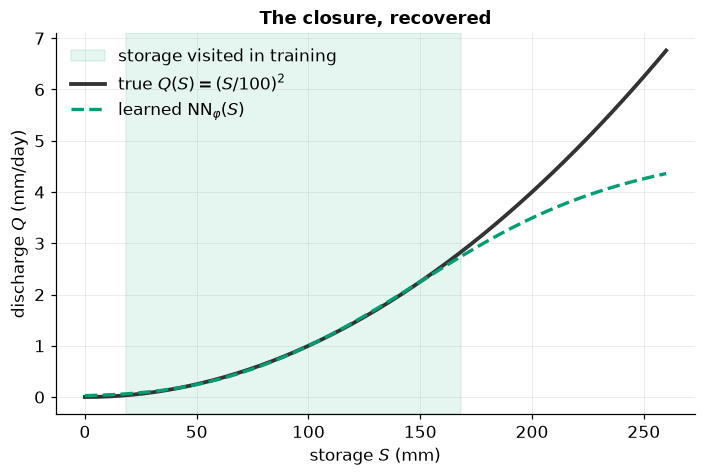

mean |error| inside the training range (18-168 mm): 0.014 mm/day
mean |error| above it (168-260 mm)               : 0.973 mm/day


In [13]:
S_grid = torch.linspace(0., 260., 200)
with torch.no_grad():
    q_learned = ude.discharge(S_grid)

lo, hi = float(S_train.min()), float(S_train.max())

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.axvspan(lo, hi, color=COLORS["hybrid"], alpha=0.10,
           label="storage visited in training")
ax.plot(S_grid, q_true(S_grid), color=COLORS["obs"], lw=2.5,
        label=r"true $Q(S) = (S/100)^2$")
ax.plot(S_grid, q_learned, color=COLORS["hybrid"], ls="--", lw=2.2,
        label=r"learned $\mathrm{NN}_\varphi(S)$")
ax.set_xlabel("storage $S$ (mm)")
ax.set_ylabel("discharge $Q$ (mm/day)")
ax.set_title("The closure, recovered")
ax.legend(loc="upper left")
plt.show()

inside = (S_grid >= lo) & (S_grid <= hi)
err_in = float((q_learned[inside] - q_true(S_grid[inside])).abs().mean())
err_out = float((q_learned[~inside & (S_grid > hi)]
                 - q_true(S_grid[~inside & (S_grid > hi)])).abs().mean())
print(f"mean |error| inside the training range ({lo:.0f}-{hi:.0f} mm): {err_in:.3f} mm/day")
print(f"mean |error| above it ({hi:.0f}-260 mm)               : {err_out:.3f} mm/day")

Inside the range of storages the model actually visited, the network recovered a
function it was never shown — from discharge observations alone, with storage
never observed at all. That is what a hybrid model buys you that a black box does
not: a component you can plot, compare against theory, and argue about.

Outside that range it is extrapolating, and the error grows. Say this on every
such figure. A learned closure is an interpolant over the conditions in your
training data, and {cite}`kalauni2025hybrid` are explicit that the next question —
how to turn a recovered curve into a written equation — is open. Rackauckas's
sparse-regression recovery of Lotka-Volterra's missing terms works, but their own
robustness study puts the recovery rate at $(50.4 \pm 25.7)\%$ across 498
error-free runs {cite}`rackauckas2021universal`. Notebook `07_open_questions`
picks this up.

## 6. Where PINNs sit, briefly

A **physics-informed neural network** {cite}`raissi2019physics` is a different
problem setup, and the workshop must not blur the two.

A PINN trains a network to *be the solution surface*:
$\hat{\psi} = \mathrm{NN}_\varphi(z, t)$, with a loss that penalizes (i) mismatch
with observed data points and (ii) the PDE residual, evaluated by differentiating
the network with respect to its own *inputs*. The network replaces **the
solution**, not **a process**. Three consequences follow, and they are the ones
that matter operationally:

- A PINN is tied to one initial/boundary-condition pair. Change the rainfall and
  you retrain.
- It uses no classical solver, so a century of work on stable, efficient,
  conservative discretizations is left on the table — Rackauckas's criticism is
  that framing the solution process "as a large optimization … does not
  incorporate the numerical techniques which have led to stable and efficient
  solvers" {cite}`rackauckas2021universal`.
- What it buys, in exchange, is a mesh-free solution and a natural route to
  inverse problems in sparse-data settings {cite}`karniadakis2021physics`.

The UDEs in this workshop keep the solver and learn a *term*. A PINN discards the
solver and learns the *answer*. They overlap — both are differentiable, both use
autograd in an unusual direction — but they are not the same tool and they fail in
different ways. You'll see a PINN and a hybrid solver side by side on Richards'
equation in the advanced material.

## Your turn

Pick one. Ten minutes.

1. **Break the adjoint on purpose, then fix it.** In the §2 stability table, find
   the number of reverse steps at which `u(0) recovered` first departs from 100
   by more than 1%. Now try $k = 12$ (a two-hour residence time). How many reverse
   steps do you need? What does that imply about using `odeint_adjoint` on a
   coupled model with a fast surface store?

2. **Move the question mark.** Change `HybridBucket` so the *ET* relation is
   learned and the storage-discharge relation is known — i.e. swap which term is
   $f$ and which is $\mathrm{NN}_\varphi$. Retrain and plot the recovered ET
   curve against the true `evapo`. Is it recovered as cleanly? Why not?

:::{dropdown} Solution — what you should see

**1.** At $k = 6$ the 1% threshold falls between 100 and 40 reverse steps —
100 steps recovers $u(0) = 99.84$, and 40 steps already gives $95.83$, a 4% error
($k\Delta t = 0.30$ and $0.75$ respectively, both comfortably inside the *stability*
limit; accuracy degrades well before stability does). At $k = 12$ you need roughly
twice as many steps for the same accuracy, because what matters is
$k\,\Delta t$ against RK4's stability limit of 2.79 — so the required step count
scales linearly with the *fastest* rate in the system. In a coupled model the
fastest rate might be a surface store with a 30-minute residence time, which would
force the reverse solve to take steps far smaller than the forward solve needed.
That is precisely the regime where the reverse-solve adjoint is the wrong tool,
and why {cite}`kalauni2025hybrid` use an implicit solver with checkpointing
rather than a backsolve.

**2.** ET is recovered much less cleanly, and the reason is identifiability, not
capacity. Discharge is what we observe, and $Q$ depends on ET only *indirectly*,
through its effect on storage. Several different ET curves produce nearly the same
hydrograph by trading off against the storage trajectory — this is equifinality
{cite}`beven2006manifesto`, and differentiability does not abolish it. The lesson
generalizes: **put the question mark where your observations can see it.** When
they can't, expect to need either a second data stream or a stronger prior.

```python
class HybridET(HybridBucket):
    def forward(self, P, E, S0=80.0):
        S = torch.tensor(S0)
        out = []
        for t in range(len(P)):
            q = q_true(S)                                  # now known
            et = E[t] * torch.sigmoid(self.net((S / S_REF).unsqueeze(-1)).squeeze(-1))
            S = S + P[t] - et - q
            out.append(q)
        return torch.stack(out)
```
:::

## Takeaways

- Your model's update rule is a solver applied to a differential equation. Write
  the right-hand side and the solver becomes a choice you make, not one you
  inherit — and RK4 validated against an analytic solution converges at fourth
  order, so you can check it.
- **Discretize-then-optimize** tapes the solver and gives the exact gradient of
  what you computed, at a memory cost of about 21 graph nodes per RK4 step.
  The **continuous adjoint** gets $O(1)$ memory by re-solving the ODE backwards,
  and that reverse solve is unstable on stiff systems — in our example a coarse
  reverse solve recovered $u(0) = 0.73$ instead of $100$ and the gradient was
  wrong by sixteen orders of magnitude, silently.
- A **neural ODE** is the special case where the entire right-hand side is a
  network. It is the *end* of a spectrum: it fit the training year and then lost
  most of its skill on a held-out year, while a UDE that kept mass balance held
  NSE $\approx 1$ on both.
- Every hybrid model in this workshop is one of **five forms**. Knowing which one
  you are building tells you what you are claiming to know and what you are
  asking the data to supply.
- A form-2 UDE recovered a storage-discharge relation it was never shown, from
  discharge alone — *within the range of storages it visited*. Outside that range
  it extrapolates, and you must say so on the figure.

## Where next

The applications notebooks build these forms on real basins:
`03_hybrid_bucket_model` (form 3), `04_dynamic_parameterization` (form 1, the
Lamichhane & Bennett design), and `05_hybrid_as_diagnostic` (form 2, the Kalauni
design, used as an instrument rather than a predictor).

## References

```{bibliography}
:filter: docname in docnames
```